#Kmeans

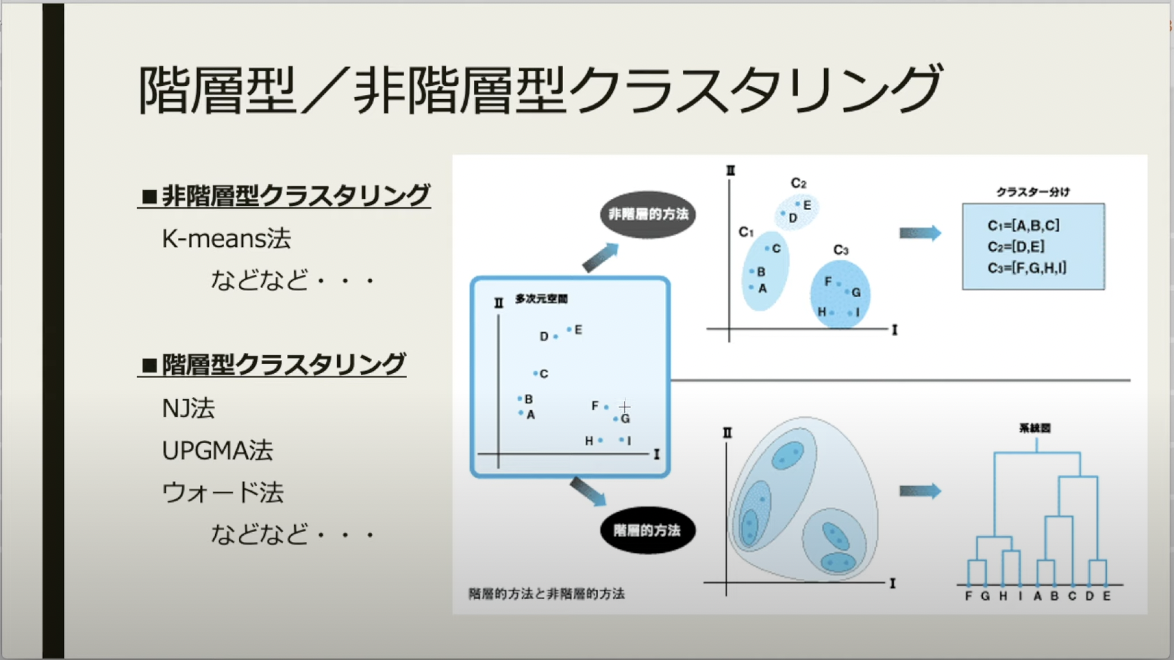

In [ ]:
# 階層型クラスタリング -> まとめるが、近い順にまとめる
# 非階層型クラスタリング -> グループ別に分ける(kmeansだけ知っていれば問題ない)

# クラスタリング - データを近い者同士でグルーピングする教師なし学習の手法

# 非階層型クラスタリング kmeans

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/4-2_skill_level.csv",index_col=0)

In [4]:
from sklearn.cluster import KMeans
vec = KMeans(n_clusters=3) #何グループに分けるかは人間側が設定しないといけない(引数 -> n_clusters=クラスター数),後で調整すれば良いため仮に数字を入れる

In [7]:
group_num = vec.fit_predict(df) #引数に何のデータを使うのか指定
#これでグループが分けられた

group_num
# 15人いるのを3グループに分けた,kmeansは実行のたびに結果が変わる
# 変なデータでなければ基本は問題はない

array([1, 0, 0, 1, 2, 1, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

#集計

In [10]:
df_calc = df.copy()
df_calc["グループ名"] = group_num #df.calc"グループ名"という列をgroup.numに追加する
df_calc #グループ名が追加された,これでどのような数字が入っているのかわかる

,コミュニケーション,リーダーシップ,プログラミング,ネットワーク知識,セキュリティ知識,グループ名
A,7,6,9,10,8,1
B,2,2,4,3,5,0
C,7,5,6,5,7,0
D,7,6,10,9,9,1
E,9,9,3,4,6,2
F,6,6,9,9,8,1
G,3,2,5,6,4,0
H,10,9,9,8,10,2
I,5,4,8,5,7,0
J,2,2,4,3,2,0


In [11]:
# グループごとの平均値を出してみる
df_calc.groupby("グループ名").mean() 

#グループの情報がわかる

,コミュニケーション,リーダーシップ,プログラミング,ネットワーク知識,セキュリティ知識
グループ名,,,,,
0,4.000000,3.25,5.500000,5.375000,5.375000
1,6.666667,6.00,9.333333,9.333333,8.333333
2,9.000000,9.25,6.250000,6.750000,8.000000


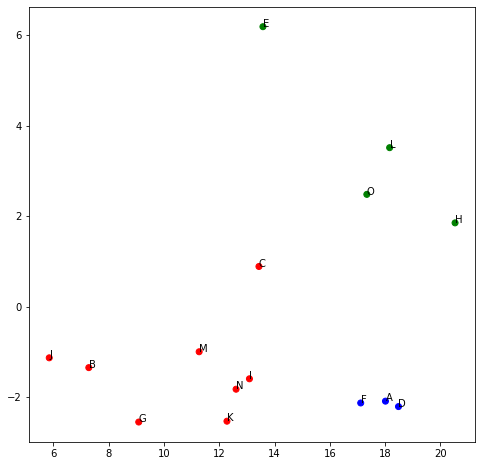

In [15]:
# グループごとに色をつけてみる

from sklearn.decomposition import TruncatedSVD

model_svd = TruncatedSVD(n_components=2)
vecs_list = model_svd.fit_transform(df)

X = vecs_list[:,0] 
Y = vecs_list[:,1]

plt.figure(figsize=(8,8))

color_codes = {0:"red",1:"blue",2:"green"}
colors = [color_codes[x] for x in group_num] #リスト内包表記
plt.scatter(X,Y,color=colors) #color = 色指定 

for i,(annot_x,annot_y) in enumerate(zip(X,Y)): 
    plt.annotate(df.index[i],(annot_x,annot_y))
plt.show()

# グループが固まっていない場合、指定が不適切
# データが大きて結果が収束していない場合 max_iter=300(default))の数字を変える(データ数を変更できる)
# vec = KMeans(n_clusters=3,max_iter=1000(例))